In [1]:
!pip install pandas seaborn matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/complete.csv")
df = df.rename(columns={ "M-Labels": "M_labels", "V-Labels": "V_labels", "L-Label": "L_labels"})
df

,Study,Title,Year,Agent Constructed,Agent-Agent Interactions,Agent-Environment Interactions,Environment,Decision-Making & Actions,Observations,Evaluation and Validation Techniques,Limitation and Challenges,Domain,M_labels,V_labels,L_labels
0,1,A deep reinforcement learning approach to conc...,2020,Buyer agent negotiates concurrently with multi...,One-to-many bilateral negotiations,Dynamic e-market,Simulated e-market,Actor–critic DRL + supervised pre-training,"Dialogue histories, opponent features",Uavg = Average utility (buyer profit in succes...,Opponents: fixed-but-unknown sellers; no adapt...,auction,"M2, M9",V13,"L4, L8"
1,2,Intelligent strategic bidding in competitive e...,2024,"Generator, buyer, ISO agents",Multi-agent bidding game,Market demand + clearing outcomes,MAS electricity market,DQN/DDQN/Async QL,"Price, demand, rewards","convergence, variation in demand and supply ra...",practical application is limited,housing,M1,"V7, V13",L3
2,3,Deep reinforcement learning in agent based fin...,2020,DRL trader + FCN traders,Interact via LOB,Environment = order-book state,Price–order-book simulator,DRL trading policy,"Mid-price, order flow","1. Metrics: Average reward, Sharpe ratio, Maxi...",Historical data is limited \n,finance,"M1, M3","V4, V5, V10, V12, V13",L4
3,4,A reinforcement learning algorithm for Agent-b...,2015,Generator/retailer agents,Strategic bidding,Market load + prices,ACE electricity simulator,Q-learning + AC-style RL,"Costs, clearing prices",Oligpolistic Competition - best performing amo...,Supplier perspective,electricity,"M1, M2","V2, V10, V13",L1
4,5,A multi-agent model of urban processes: Modell...,2011,Household & dwelling agents,Search & bargaining,Market conditions feedback,Urban housing market,"Expected utility, probabilistic choice","Vacancy, prices",Simulation experiments with 600 households & d...,Budget constraints simplified. \n Bargaining ...,housing,M6,"V7, V8, V13","L1, L6"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,63,Agent-based simulation-an application to the n...,2001,"Generator, supplier, operator",Bilateral trades,Settlement/imbalance,UK NETA,RL pricing,Settlement results,Pre-implementation policy evaluation (pricing/...,Computational cost; limited cross-market gener...,electricity,M1,"V7, V9, V14","L3, L6"
62,64,Agent-based simulation of consumer purchase de...,2007,Consumer agents,Influence & imitation,Marketing stimuli,Consumer market,Motivation-based choice,Product attributes,Emergence of decoy effect; price–quality sensi...,Abstracted; lacks empirical calibration.,consumer,"M5, M6","V11, V13","L2, L7"
63,65,Heterogeneity and feedback in an agent-based m...,2005,Traders,Indirect via order flow,Price feedback,Single-asset market,Strategy updates,Price movement,Stylized facts validation (volatility clusteri...,No strategic learning; single-asset simplifica...,finance,M3,V5,"L1, L8"
64,66,Deep reinforcement learning-based optimal bidd...,2024,GenCo bidding agents,Compete via bids,Load feedback,Real-time market simulator,PPO bidding,"Prices, loads",Fixed vs time-varying load experiments; Nash-l...,Scalability/observability assumptions.,electricity,M2,"V7, V12, V13","L1, L11"


In [3]:
assert {"Study", "Year", "Domain", "M_labels", "V_labels", "L_labels"}.issubset(df.columns)

## Data Preprocessing -
Flattening table, and separating tables

In [4]:
def explode_labels(df, label_col, label_prefix):
    temp = df[["Study", "Year", "Domain", label_col]].copy()
    temp = temp.dropna(subset=[label_col])
    temp[label_col] = temp[label_col].astype(str).str.split(",")
    temp = temp.explode(label_col)
    temp[label_col] = temp[label_col].str.strip()
    temp = temp[temp[label_col].str.startswith(label_prefix)]
    return temp

In [5]:
m_df = explode_labels(df,'M_labels','M')
v_df = explode_labels(df,'V_labels','V')
l_df = explode_labels(df,'L_labels','L')

In [6]:
m_df #methodology

,Study,Year,Domain,M_labels
0,1,2020,auction,M2
0,1,2020,auction,M9
1,2,2024,housing,M1
2,3,2020,finance,M1
2,3,2020,finance,M3
...,...,...,...,...
62,64,2007,consumer,M5
62,64,2007,consumer,M6
63,65,2005,finance,M3
64,66,2024,electricity,M2


In [7]:
l_df #limitation

,Study,Year,Domain,L_labels
0,1,2020,auction,L4
0,1,2020,auction,L8
1,2,2024,housing,L3
2,3,2020,finance,L4
3,4,2015,electricity,L1
...,...,...,...,...
63,65,2005,finance,L8
64,66,2024,electricity,L1
64,66,2024,electricity,L11
65,67,2024,electricity,L1


In [8]:
v_df #validation

,Study,Year,Domain,V_labels
0,1,2020,auction,V13
1,2,2024,housing,V7
1,2,2024,housing,V13
2,3,2020,finance,V4
2,3,2020,finance,V5
...,...,...,...,...
64,66,2024,electricity,V7
64,66,2024,electricity,V12
64,66,2024,electricity,V13
65,67,2024,electricity,V7


## Percentage Tables

In [9]:
def label_percentage_table(df, label_col, all_labels=None):
    """
    df         : exploded dataframe (one label per row)
    label_col  : column with labels (e.g. 'M_labels' or 'V_labels')
    all_labels : list of all possible label codes to include (e.g., ['M1', ..., 'M13'])
                 If provided, labels with 0 count will still appear.
    """
    labels = (
        df[label_col]
        .dropna()
        .astype(str)
        .str.strip()
    )

    counts = labels.value_counts()

    if all_labels is not None:
        counts = counts.reindex(all_labels, fill_value=0)

    total = counts.sum()
    percentages = counts / total * 100 if total > 0 else 0

    summary_df = pd.DataFrame({
        "code": counts.index,
        "count": counts.values,
        "percentage": percentages.values
    })

    return summary_df


In [10]:
#methodology
m_df = explode_labels(df, 'M_labels', 'M')
all_M_codes = [f"M{i}" for i in range(1, 11)]  # M1–M13
m_summary = label_percentage_table(m_df, "M_labels", all_labels=all_M_codes)
print(m_summary)

  code  count  percentage
0   M1     10   10.309278
1   M2      4    4.123711
2   M3     42   43.298969
3   M4      1    1.030928
4   M5      6    6.185567
5   M6     15   15.463918
6   M7      8    8.247423
7   M8      1    1.030928
8   M9      9    9.278351
9  M10      1    1.030928


In [11]:
v_df = explode_labels(df, 'V_labels', 'V')
all_V_codes = [f"V{i}" for i in range(1, 15)]
v_summary = label_percentage_table(v_df, "V_labels", all_labels=all_V_codes)
v_summary

,code,count,percentage
0,V1,7,4.516129
1,V2,20,12.903226
2,V3,9,5.806452
3,V4,3,1.935484
4,V5,11,7.096774
5,V6,3,1.935484
6,V7,7,4.516129
7,V8,5,3.225806
8,V9,14,9.032258
9,V10,3,1.935484


In [12]:
l_df = explode_labels(df, 'L_labels', 'L')
all_L_codes = [f"L{i}" for i in range(1, 12)]
l_summary = label_percentage_table(l_df, "L_labels", all_labels=all_L_codes)
l_summary

,code,count,percentage
0,L1,32,25.6
1,L2,10,8.0
2,L3,12,9.6
3,L4,5,4.0
4,L5,3,2.4
5,L6,10,8.0
6,L7,16,12.8
7,L8,28,22.4
8,L9,1,0.8
9,L10,5,4.0


## Adoption over the years

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/complete.csv")

def prepare_label_long(df, year_col, label_col):
    """
    df        : original dataframe
    year_col  : name of the year column (e.g., 'Year')
    label_col : name of the label column (e.g., 'M_labels')

    Returns: long dataframe with columns [year_col, 'Label']
             one row per (Year, Label) occurrence
    """
    tmp = df[[year_col, label_col]].dropna()

    tmp[label_col] = (
        tmp[label_col]
        .astype(str)
        .str.replace(r"\s+", "", regex=True)
        .str.split(",")
    )
    tmp = tmp.explode(label_col)
    tmp = tmp.rename(columns={label_col: "Label"})
    return tmp


In [14]:
df = pd.read_csv("../data/complete.csv")
print(df.columns.tolist())

['Study', 'Title', 'Year', 'Agent Constructed', 'Agent-Agent Interactions', 'Agent-Environment Interactions ', 'Environment', 'Decision-Making & Actions', 'Observations', 'Evaluation and Validation Techniques', 'Limitation and Challenges', 'Domain', 'M-Labels', 'V-Labels', 'L-Label']


In [15]:
YEAR_COL = "Year"
m_long = prepare_label_long(df, YEAR_COL, "M-Labels")
m_counts = (
    m_long
    .groupby([YEAR_COL, "Label"])
    .size()
    .reset_index(name="Count")
)

m_counts_pivot = (
    m_counts
    .pivot(index=YEAR_COL, columns="Label", values="Count")
    .fillna(0)
    .astype(int)
    .sort_index(axis=1)
)

print("M-label counts per year:")
print(m_counts_pivot)


M-label counts per year:
Label  M1  M10  M2  M3  M4  M5  M6  M7  M8  M9
Year                                          
2001    1    0   0   1   0   0   1   0   0   0
2003    0    0   0   1   0   0   0   0   0   0
2005    0    0   0   2   0   0   0   0   0   0
2007    0    0   0   2   0   1   2   0   0   0
2008    0    0   0   1   0   0   0   1   0   0
2009    0    0   0   3   1   1   0   1   0   1
2010    0    0   0   1   0   1   2   0   0   1
2011    0    0   0   1   0   0   2   1   0   0
2012    0    0   0   3   0   0   1   0   0   2
2013    1    0   0   3   0   0   1   2   0   0
2015    1    0   1   2   0   0   0   0   0   0
2016    0    0   0   1   0   1   1   1   0   1
2017    0    0   0   3   0   0   0   1   0   2
2018    0    0   0   2   0   0   0   0   0   1
2019    1    0   0   2   0   0   1   0   0   0
2020    2    0   1   4   0   0   0   0   0   1
2021    0    1   0   1   0   1   2   0   0   0
2023    0    0   1   5   0   1   1   0   0   0
2024    4    0   1   4   0   0   1 

In [16]:
v_long = prepare_label_long(df, YEAR_COL, "V-Labels")
v_counts = (
    v_long
    .groupby([YEAR_COL, "Label"])
    .size()
    .reset_index(name="Count")
)

v_counts_pivot = (
    v_counts
    .pivot(index=YEAR_COL, columns="Label", values="Count")
    .fillna(0)
    .astype(int)
    .sort_index(axis=1)
)

print("\nV-label counts per year:")
print(v_counts_pivot)


V-label counts per year:
Label  V1  V10  V11  V12  V13  V14  V2  V3  V4  V5  V6  V7  V8  V9
Year                                                              
2001    0    0    1    0    0    1   0   0   0   0   0   1   0   2
2003    0    0    1    0    0    0   0   0   0   0   0   0   0   1
2005    0    0    0    0    0    0   1   0   0   1   0   0   0   1
2007    2    0    4    0    2    0   2   0   0   0   0   0   0   0
2008    0    0    0    0    1    0   1   0   0   0   0   0   1   0
2009    0    0    3    0    2    0   0   1   0   0   0   0   1   3
2010    1    0    2    0    1    0   2   1   0   1   0   0   0   0
2011    0    0    0    0    2    1   0   1   0   0   0   1   1   1
2012    0    0    1    1    3    1   3   0   0   1   0   0   0   1
2013    1    1    1    0    2    1   2   1   0   2   0   0   0   0
2015    0    1    0    0    3    0   2   1   0   0   1   0   0   0
2016    0    0    0    1    3    0   0   0   0   0   0   0   1   1
2017    0    0    1    0    1    1  

In [17]:
l_long = prepare_label_long(df, YEAR_COL, "L-Label")
l_counts = (
    l_long
    .groupby([YEAR_COL, "Label"])
    .size()
    .reset_index(name="Count")
)

l_counts_pivot = (
    l_counts
    .pivot(index=YEAR_COL, columns="Label", values="Count")
    .fillna(0)
    .astype(int)
    .sort_index(axis=1)
)

print("\nL-label counts per year:")
print(l_counts_pivot)


L-label counts per year:
Label  L1  L10  L11  L2  L3  L4  L5  L6  L7  L8  L9
Year                                               
2001    0    0    0   1   1   0   0   1   0   1   0
2003    1    0    0   0   0   0   0   0   1   0   0
2005    2    0    0   0   0   0   0   0   0   2   0
2007    0    1    0   1   1   0   1   1   1   0   0
2008    0    0    0   0   0   0   0   0   0   1   0
2009    5    1    0   0   0   0   0   0   0   2   0
2010    2    0    0   0   1   1   0   1   1   2   0
2011    3    0    0   0   0   0   0   1   0   2   0
2012    1    0    0   1   2   0   1   0   3   0   0
2013    4    0    0   1   0   0   0   2   0   3   0
2015    1    0    0   1   1   0   0   0   2   1   0
2016    2    0    1   0   0   1   0   0   0   1   0
2017    2    0    0   0   0   0   0   1   1   1   0
2018    0    0    1   1   0   0   0   0   1   1   0
2019    1    0    0   1   1   0   0   0   1   1   0
2020    0    1    0   1   1   2   0   1   2   2   0
2021    1    1    0   1   0   0   1   

In [18]:
def plot_adoption_bubble(
    plot_title,
    pivot_df,
    title,
    value_label="Value",
    label_map=None,
    x_label="Methodology"
):
    import matplotlib.pyplot as plt
    import seaborn as sns

    year_col = pivot_df.index.name or "Year"
    tmp = pivot_df.reset_index()

    long_df = tmp.melt(
        id_vars=year_col,
        var_name="Code",
        value_name=value_label
    )

    # remove zeros
    long_df = long_df.dropna(subset=[value_label])
    long_df = long_df[long_df[value_label] > 0]

    # ✅ combine M-code + descriptive label
    if label_map is not None:
        long_df["Label"] = long_df.apply(
            lambda r: f"{r['Code']}: {label_map.get(r['Code'], r['Code'])}",
            axis=1
        )
        x_var = "Label"
    else:
        x_var = "Code"

    plt.figure(figsize=(12, 7), dpi=100)
    sns.set_style("whitegrid")

    ax = sns.scatterplot(
        data=long_df,
        x=x_var,
        y=year_col,
        size=value_label,
        hue=value_label,      # same variable
        legend="brief",       # ← prevents duplicate legends
        palette="RdYlGn",
        sizes=(50, 400),
        alpha=0.75,
        edgecolor="darkgray",
        linewidth=1.2
    )

    ax.set_xlabel(x_label, fontsize=12, fontweight="bold")
    ax.set_ylabel("Year", fontsize=12, fontweight="bold")

    plt.xticks(rotation=30, ha="right")

    ax.legend(
    title=value_label,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # right side, vertically centered
    frameon=True
    )


    plt.title(plot_title, fontsize=13, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", bbox_inches="tight")
    plt.show()

In [19]:
def plot_adoption_bubble(
    plot_title,
    pivot_df,
    title,
    prefix=None,
    value_label="Value",
    x_label="Methodology"
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import re

    year_col = pivot_df.index.name or "Year"
    tmp = pivot_df.reset_index()

    long_df = tmp.melt(
        id_vars=year_col,
        var_name="Code",
        value_name=value_label
    )

    # Keep only the requested category: M, V, or L
    if prefix is not None:
        long_df = long_df[
            long_df["Code"].astype(str).str.startswith(prefix)
        ]

    # Remove missing and zero values
    long_df = long_df.dropna(subset=[value_label])
    long_df = long_df[long_df[value_label] > 0]

    # Natural ordering: M1, M2, ..., M10
    code_order = sorted(
        long_df["Code"].unique(),
        key=lambda code: int(re.search(r"\d+", str(code)).group())
    )

    long_df["Code"] = pd.Categorical(
        long_df["Code"],
        categories=code_order,
        ordered=True
    )

    plt.figure(figsize=(12, 7), dpi=100)
    sns.set_style("whitegrid")

    ax = sns.scatterplot(
        data=long_df,
        x="Code",
        y=year_col,
        size=value_label,
        hue=value_label,
        legend="brief",
        palette="RdYlGn",
        sizes=(50, 400),
        alpha=0.75,
        edgecolor="darkgray",
        linewidth=1.2
    )

    ax.set_xlabel(x_label, fontsize=12, fontweight="bold")
    ax.set_ylabel("Year", fontsize=12, fontweight="bold")

    plt.xticks(rotation=0)

    ax.legend(
        title=value_label,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True
    )

    plt.title(
        plot_title,
        fontsize=13,
        fontweight="bold",
        pad=20
    )

    plt.tight_layout()
    plt.savefig(
        f"{title.replace(' ', '_')}.png",
        bbox_inches="tight",
        dpi=300
    )
    plt.show()

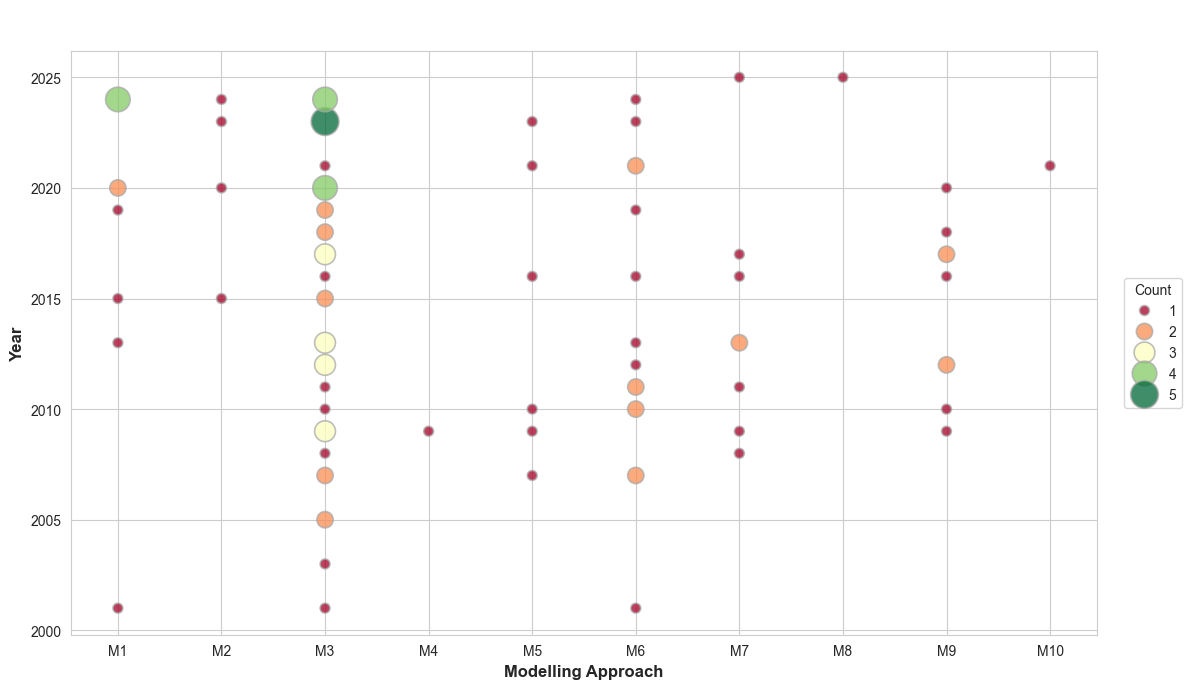

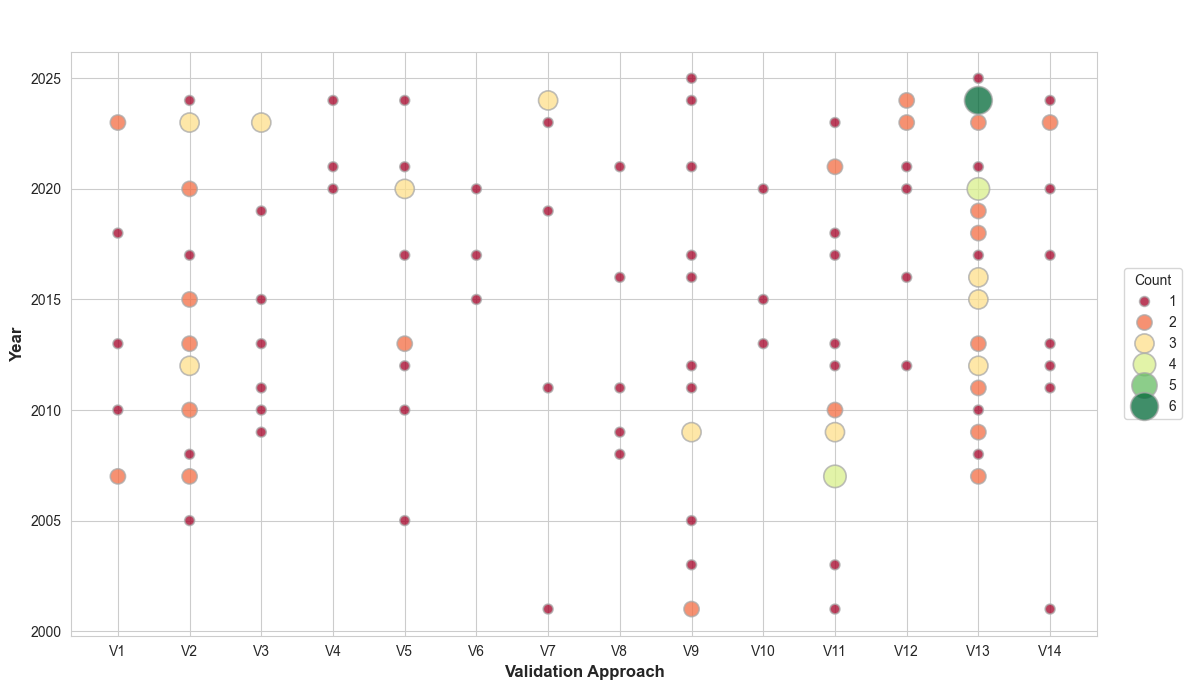

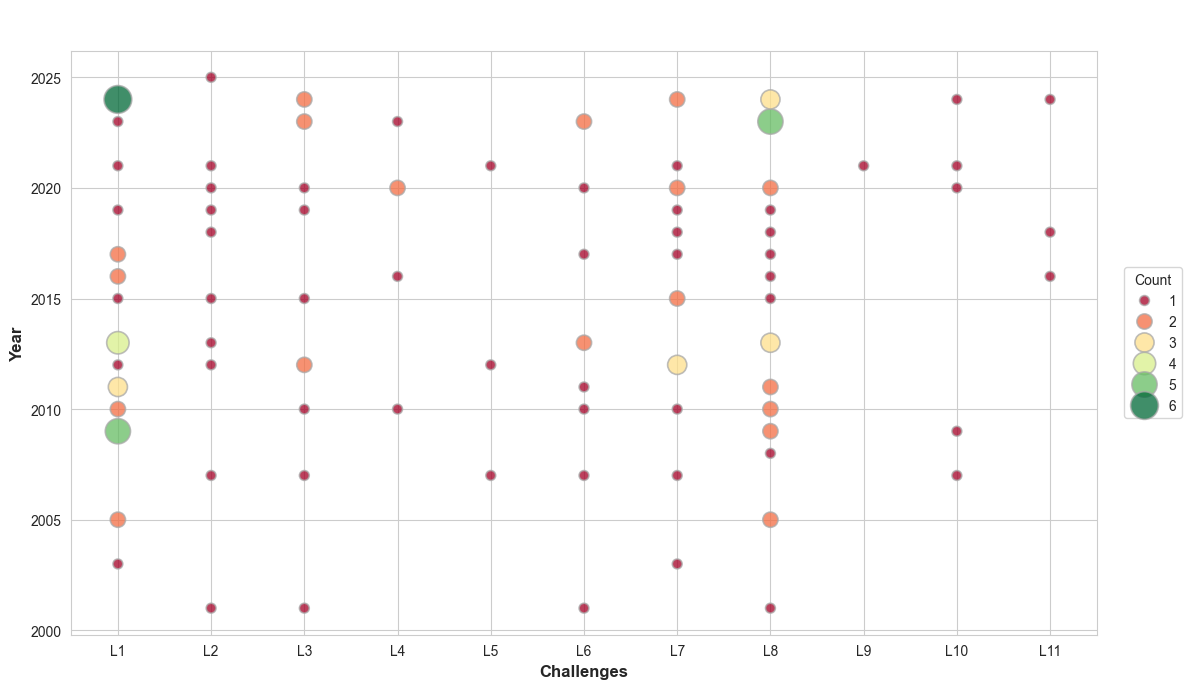

In [20]:
# Modelling approaches
plot_adoption_bubble(
    plot_title=" ",
    pivot_df=m_counts_pivot,
    title=" ",
    prefix="M",
    value_label="Count",
    x_label="Modelling Approach"
)

# Validation approaches
plot_adoption_bubble(
    plot_title=" ",
    pivot_df=v_counts_pivot,
    title=" ",
    prefix="V",
    value_label="Count",
    x_label="Validation Approach"
)

# Learning or other L categories
plot_adoption_bubble(
    plot_title=" ",
    pivot_df=l_counts_pivot,
    title=" ",
    prefix="L",
    value_label="Count",
    x_label="Challenges"
)

## Domain Specific Mapping

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import re

df = pd.read_csv('../data/complete.csv')
df.columns = df.columns.str.strip()

def natural_label_order(columns):
    return sorted(columns, key=lambda label: int(re.search(r"\d+", str(label)).group()))

In [33]:
def parse_labels(x):
    if pd.isna(x):
        return []
    return [lbl.strip() for lbl in str(x).split(',') if lbl.strip()]

df['M_list'] = df['M-Labels'].apply(parse_labels)
df['V_list'] = df['V-Labels'].apply(parse_labels)
df['L_list'] = df['L-Label'].apply(parse_labels)

In [34]:
m_exploded = df[['Domain', 'M_list']].explode('M_list').dropna().rename(columns={'M_list': 'Label'})
v_exploded = df[['Domain', 'V_list']].explode('V_list').dropna().rename(columns={'V_list': 'Label'})
l_exploded = df[['Domain', 'L_list']].explode('L_list').dropna().rename(columns={'L_list': 'Label'})

In [35]:
domain_order = ['finance', 'housing', 'electricity', 'consumer', 'retail', 'auction']

In [36]:
# Style settings
sns.set_style("white")
plt.rcParams.update({'font.size': 12,'axes.labelsize': 13,'axes.titlesize': 16,'xtick.labelsize': 11,'ytick.labelsize': 11,'figure.figsize': (10, 6)})

In [40]:
# -------------------------------
# 1. Methodology Heatmap
# -------------------------------
plt.figure()
m_heat = m_exploded.groupby(['Domain', 'Label']).size().unstack(fill_value=0)
m_heat = m_heat.reindex(domain_order)                     # ordered rows
m_heat = m_heat.reindex(columns=natural_label_order(m_heat.columns))
sns.heatmap(m_heat, annot=True, fmt='d', cmap="Blues", linewidths=.5, cbar_kws={'label': 'Number of Papers'})
# plt.title('Modelling Approaches accross Domain', fontweight='bold', pad=20)
plt.xlabel('Methodology Label')
plt.ylabel('Domain')
plt.tight_layout()
plt.savefig('01_Methodology_Heatmap_Counts.png', dpi=300, bbox_inches='tight')
plt.close()
print("Saved: 01_Methodology_Heatmap_Counts.png")

Saved: 01_Methodology_Heatmap_Counts.png


In [39]:
# -------------------------------
# 2. Validation Heatmap
# -------------------------------
plt.figure()
v_heat = v_exploded.groupby(['Domain', 'Label']).size().unstack(fill_value=0)
v_heat = v_heat.reindex(domain_order)
v_heat = v_heat.reindex(columns=natural_label_order(v_heat.columns))
sns.heatmap(v_heat, annot=True, fmt='d', cmap="Oranges", linewidths=.5, cbar_kws={'label': 'Number of Papers'})
# plt.title('Validation Approaches accross Domain', fontweight='bold', pad=20)
plt.xlabel('Validation Label')
plt.ylabel('Domain')
plt.tight_layout()
plt.savefig('02_Validation_Heatmap_Counts.png', dpi=300, bbox_inches='tight')
plt.close()
print("Saved: 02_Validation_Heatmap_Counts.png")


Saved: 02_Validation_Heatmap_Counts.png


In [41]:
# -------------------------------
# 3. Limitation Heatmap
# -------------------------------
plt.figure()
l_heat = l_exploded.groupby(['Domain', 'Label']).size().unstack(fill_value=0)
l_heat = l_heat.reindex(domain_order)
l_heat = l_heat.reindex(columns=natural_label_order(l_heat.columns))
sns.heatmap(l_heat, annot=True, fmt='d', cmap="Purples", linewidths=.5, cbar_kws={'label': 'Number of Papers'})
# plt.title('Challenges accross Domain', fontweight='bold', pad=20)
plt.xlabel('Limitation Label')
plt.ylabel('Domain')
plt.tight_layout()
plt.savefig('03_Limitation_Heatmap_Counts.png', dpi=300, bbox_inches='tight')
plt.close()
print("Saved: 03_Limitation_Heatmap_Counts.png")

Saved: 03_Limitation_Heatmap_Counts.png


## Percentage Graphs

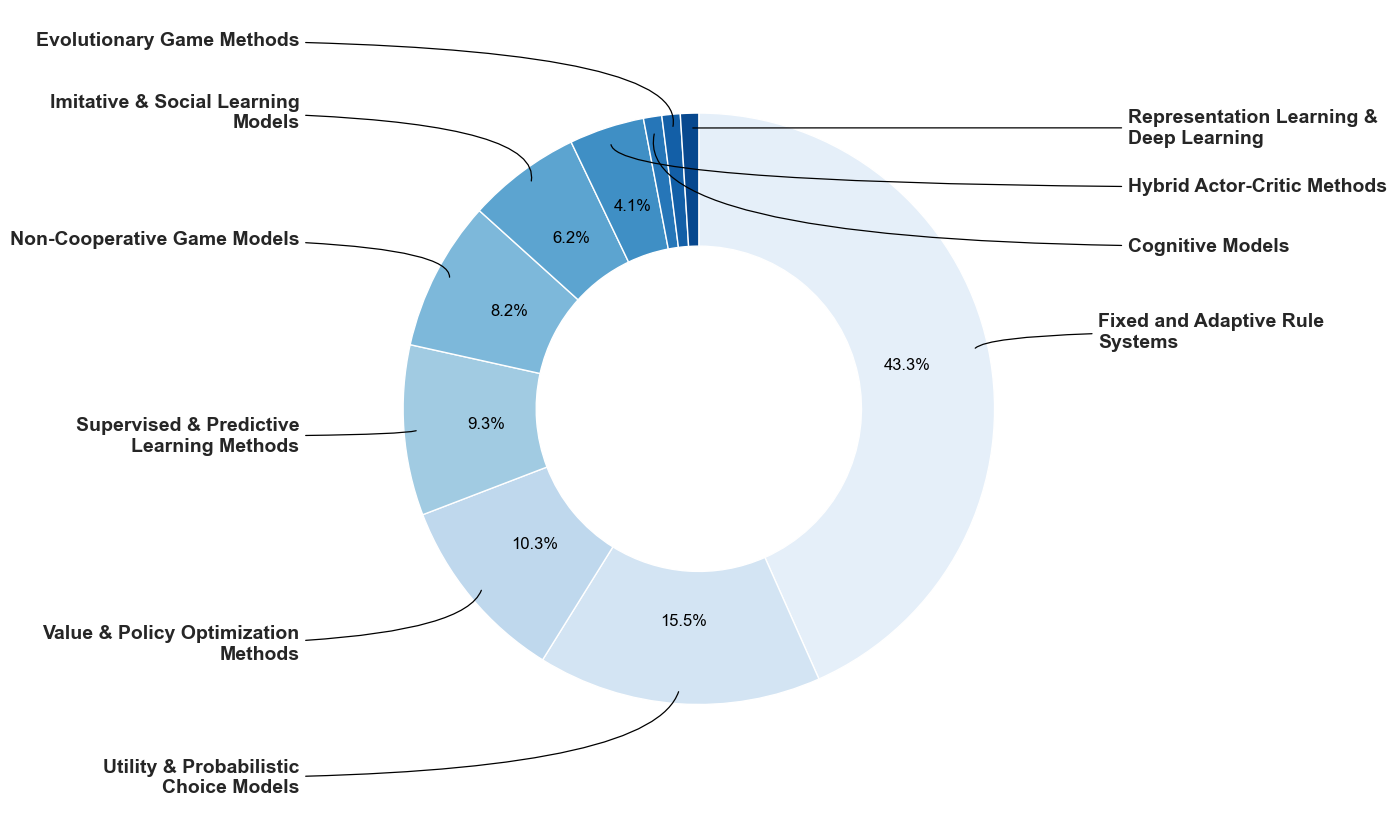

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

data = [
    ("Fixed and Adaptive Rule Systems", 42, 43.3),
    ("Utility & Probabilistic Choice Models", 15, 15.5),
    ("Value & Policy Optimization Methods", 10, 10.3),
    ("Supervised & Predictive Learning Methods", 9, 9.3),
    ("Non-Cooperative Game Models", 8, 8.2),
    ("Imitative & Social Learning Models", 6, 6.2),
    ("Hybrid Actor-Critic Methods", 4, 4.1),
    ("Cognitive Models", 1, 1.0),
    ("Evolutionary Game Methods", 1, 1.0),
    ("Representation Learning & Deep Learning", 1, 1.0),
]

df = pd.DataFrame(data, columns=["label", "count", "pct"])
df = df.sort_values("pct", ascending=False)

sns.set_theme(style="white", font_scale=1.25)

fig, ax = plt.subplots(figsize=(13, 8.5))

colors = sns.color_palette("Blues", n_colors=len(df))

wedges, texts, autotexts = ax.pie(
    df["pct"],
    startangle=90,
    counterclock=False,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
    pctdistance=0.72,
    wedgeprops=dict(width=0.45, edgecolor="white"),
    textprops=dict(color="black", fontsize=12)
)

# Increase percentage label font size
for autotext in autotexts:
    autotext.set_fontsize(12)

# Labels to force to the right
force_right = {
    "Representation Learning & Deep Learning",
    "Hybrid Actor-Critic Methods",
    "Cognitive Models"
}

manual_y = {
    "Representation Learning & Deep Learning": 0.95,
    "Hybrid Actor-Critic Methods": 0.75,
    "Cognitive Models": 0.55,
}

for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    label_text = df["label"].iloc[i]
    label = "\n".join(textwrap.wrap(label_text, width=28))

    label_x = 1.35 * np.sign(x)
    label_y = 1.25 * y
    horizontal_alignment = "left" if x > 0 else "right"

    if label_text in force_right:
        label_x = 1.45
        label_y = manual_y[label_text]
        horizontal_alignment = "left"

    ax.annotate(
        label,
        xy=(x * 0.95, y * 0.95),
        xytext=(label_x, label_y),
        ha=horizontal_alignment,
        va="center",
        fontsize=14,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=0.9,
            connectionstyle="angle3,angleA=0,angleB=75"
        )
    )

ax.set_aspect("equal")

ax.set_xlim(-1.75, 1.75)
ax.set_ylim(-1.35, 1.35)

plt.tight_layout()
plt.savefig("method_category_distribution_connected_labels.png", dpi=300, bbox_inches="tight")
plt.show()

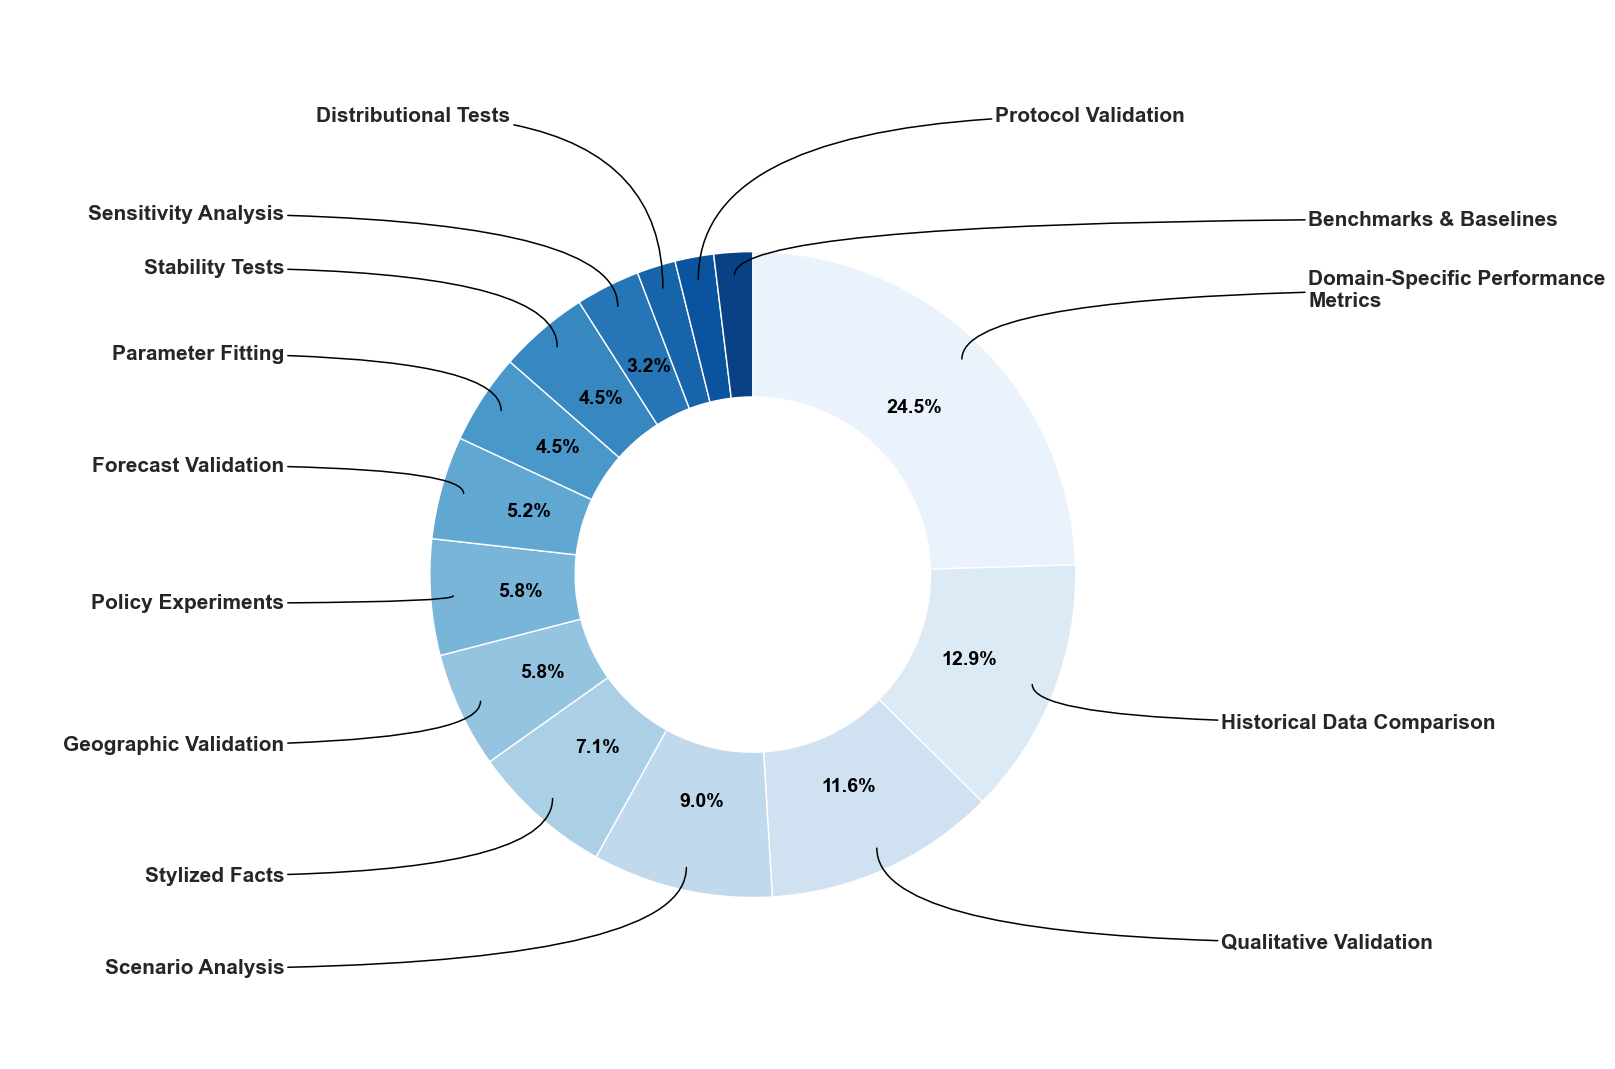

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

data = [
    ("Parameter Fitting", 4.516129),
    ("Historical Data Comparison", 12.903226),
    ("Geographic Validation", 5.806452),
    ("Distributional Tests", 1.935484),
    ("Stylized Facts", 7.096774),
    ("Protocol Validation", 1.935484),
    ("Stability Tests", 4.516129),
    ("Sensitivity Analysis", 3.225806),
    ("Scenario Analysis", 9.032258),
    ("Benchmarks & Baselines", 1.935484),
    ("Qualitative Validation", 11.612903),
    ("Forecast Validation", 5.16129),
    ("Domain-Specific Performance Metrics", 24.516129),
    ("Policy Experiments", 5.806452),
]

df = pd.DataFrame(data, columns=["label", "pct"])
df["label"] = df["label"].str.strip()
df = df.sort_values("pct", ascending=False).reset_index(drop=True)

sns.set_theme(style="white", font_scale=1.4)

fig, ax = plt.subplots(figsize=(17, 11))

colors = sns.color_palette("Blues", n_colors=len(df))

wedges, texts, autotexts = ax.pie(
    df["pct"],
    startangle=90,
    counterclock=False,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
    pctdistance=0.72,
    wedgeprops=dict(width=0.45, edgecolor="white"),
    textprops=dict(color="black", fontsize=14)
)

for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_fontweight("bold")

# Fixed manual positions
manual_positions = {
    "Distributional Tests": (-0.75, 1.42, "right"),
    "Protocol Validation": (0.75, 1.42, "left"),
    "Benchmarks & Baselines": (1.72, 1.10, "left"),
    "Domain-Specific Performance Metrics": (1.72, 0.88, "left"),
}

for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    label_text = df["label"].iloc[i]

    if label_text == "Domain-Specific Performance Metrics":
        label = "Domain-Specific Performance\nMetrics"
    else:
        label = "\n".join(textwrap.wrap(label_text, width=28))

    # default placement
    label_x = 1.45 * np.sign(x)
    label_y = 1.25 * y
    ha = "left" if x > 0 else "right"

    # manual override
    if label_text in manual_positions:
        label_x, label_y, ha = manual_positions[label_text]

    ax.annotate(
        label,
        xy=(x * 0.93, y * 0.93),
        xytext=(label_x, label_y),
        ha=ha,
        va="center",
        fontsize=15,
        fontweight="bold",
        annotation_clip=False,
        clip_on=False,
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=1.1,
            shrinkA=0,
            shrinkB=0,
            connectionstyle="angle3,angleA=0,angleB=90"
        )
    )

ax.set_aspect("equal")
ax.set_xlim(-2.3, 2.3)
ax.set_ylim(-1.5, 1.75)

plt.tight_layout()
plt.savefig("validation_category_distribution_connected_labels_fixed.png", dpi=300, bbox_inches="tight")
plt.show()

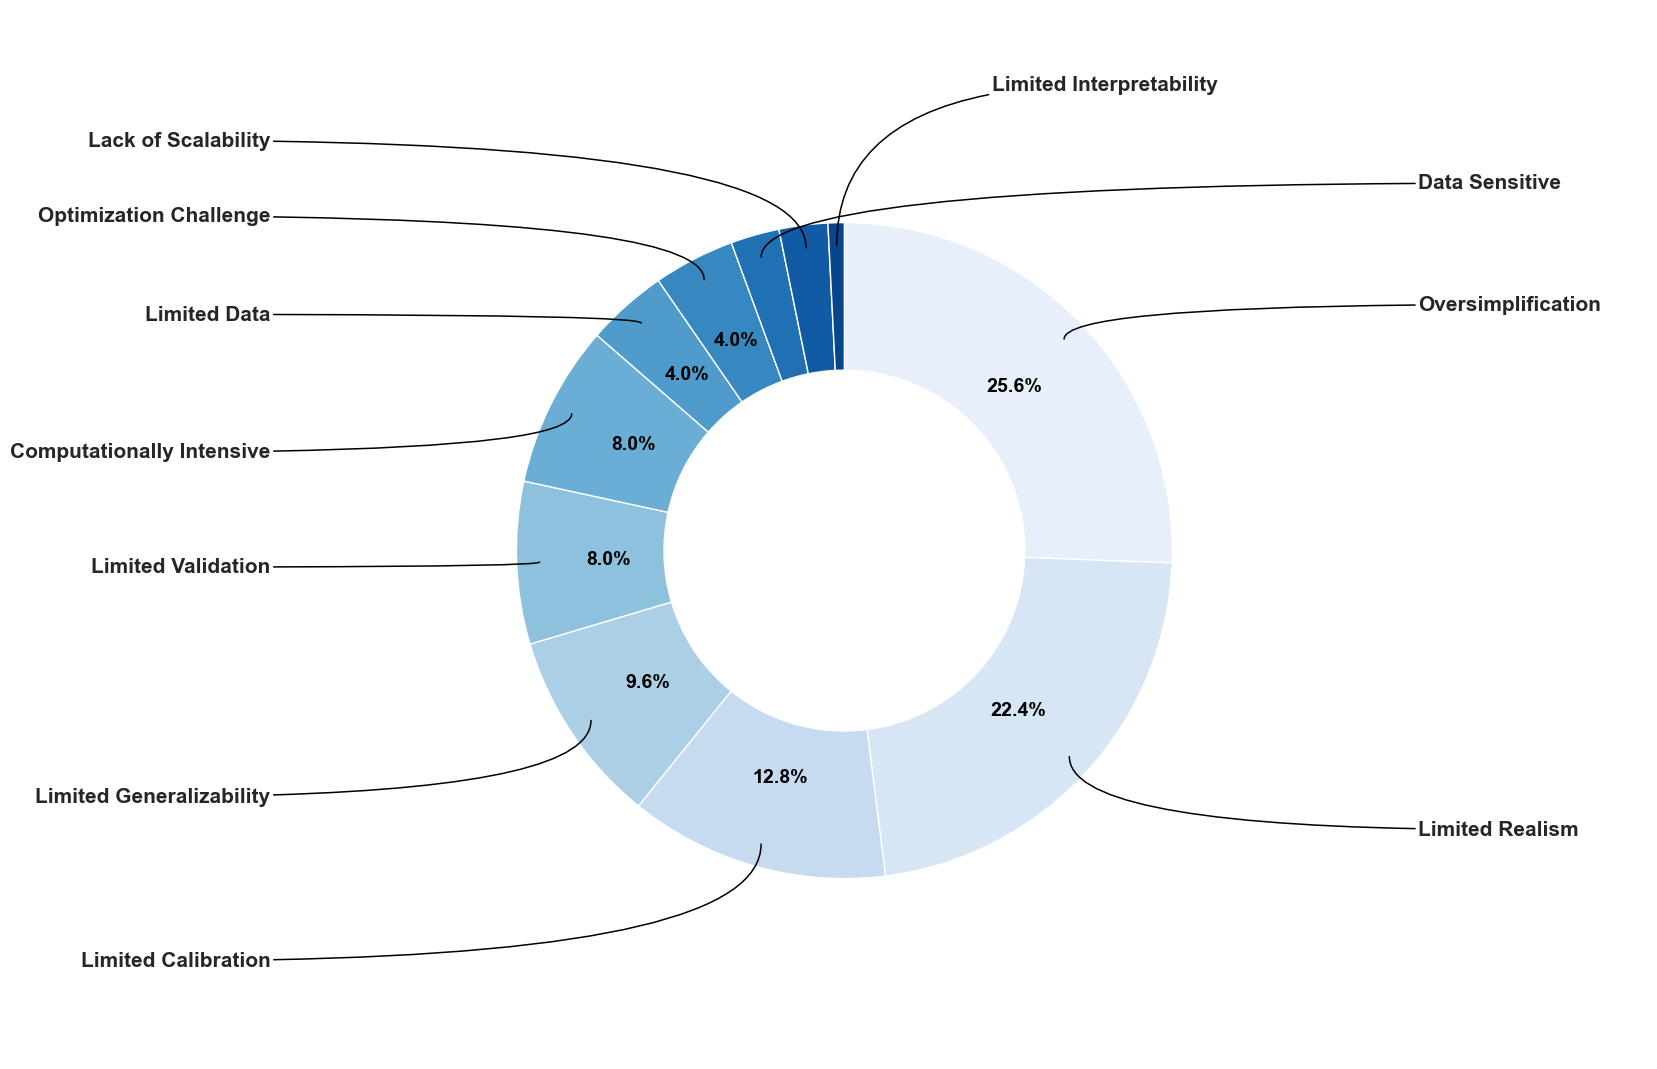

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

data = [
    ("Oversimplification", 25.6),
    ("Limited Validation", 8.0),
    ("Limited Generalizability", 9.6),
    ("Limited Data", 4.0),
    ("Data Sensitive", 2.4),
    ("Computationally Intensive", 8.0),
    ("Limited Calibration", 12.8),
    ("Limited Realism", 22.4),
    ("Limited Interpretability", 0.8),
    ("Optimization Challenge", 4.0),
    ("Lack of Scalability", 2.4),
]

df = pd.DataFrame(data, columns=["label", "pct"])
df["label"] = df["label"].str.strip()
df = df.sort_values("pct", ascending=False).reset_index(drop=True)

sns.set_theme(style="white", font_scale=1.4)

fig, ax = plt.subplots(figsize=(18, 11))

colors = sns.color_palette("Blues", n_colors=len(df))

wedges, texts, autotexts = ax.pie(
    df["pct"],
    startangle=90,
    counterclock=False,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 3 else "",
    pctdistance=0.72,
    wedgeprops=dict(width=0.45, edgecolor="white"),
    textprops=dict(color="black", fontsize=14)
)

for autotext in autotexts:
    autotext.set_fontsize(14)
    autotext.set_fontweight("bold")

# Fixed label positions to prevent overlap
manual_positions = {
    # top/right cluster
    "Limited Interpretability": (0.45, 1.42, "left"),
    "Data Sensitive": (1.75, 1.12, "left"),
    "Oversimplification": (1.75, 0.75, "left"),

    # top-left cluster
    "Lack of Scalability": (-1.75, 1.25, "right"),
    "Optimization Challenge": (-1.75, 1.02, "right"),
    "Limited Data": (-1.75, 0.72, "right"),

    # remaining labels
    "Computationally Intensive": (-1.75, 0.30, "right"),
    "Limited Validation": (-1.75, -0.05, "right"),
    "Limited Generalizability": (-1.75, -0.75, "right"),
    "Limited Calibration": (-1.75, -1.25, "right"),
    "Limited Realism": (1.75, -0.85, "left"),
}

for i, wedge in enumerate(wedges):
    angle = (wedge.theta2 + wedge.theta1) / 2
    x = np.cos(np.deg2rad(angle))
    y = np.sin(np.deg2rad(angle))

    label_text = df["label"].iloc[i]
    label = "\n".join(textwrap.wrap(label_text, width=26))

    # default position
    label_x = 1.45 * np.sign(x)
    label_y = 1.25 * y
    ha = "left" if x > 0 else "right"

    # manual override
    if label_text in manual_positions:
        label_x, label_y, ha = manual_positions[label_text]

    ax.annotate(
        label,
        xy=(x * 0.93, y * 0.93),
        xytext=(label_x, label_y),
        ha=ha,
        va="center",
        fontsize=15,
        fontweight="bold",
        annotation_clip=False,
        clip_on=False,
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=1.1,
            shrinkA=0,
            shrinkB=0,
            connectionstyle="angle3,angleA=0,angleB=90"
        )
    )

ax.set_aspect("equal")

# Extra space for large outside labels
ax.set_xlim(-2.45, 2.45)
ax.set_ylim(-1.55, 1.65)

plt.tight_layout()
plt.savefig("challenge_category_distribution_connected_labels_fixed.png", dpi=300, bbox_inches="tight")
plt.show()